### Notebook Overview — Basic Fine-Tuning

---

## Purpose

This notebook performs **targeted fine-tuning of the Multi-Layer Perceptron (MLP)** classifier for the DIP-based AI image detection pipeline.  

It refines model performance by evaluating multiple candidate configurations using cross-validation, selecting the best configuration, retraining the model, and performing final evaluation on an independent test set.  

A comparison against baseline results is also included to quantify performance improvements.

---

## Inputs

The notebook requires the following inputs:

- Normalized training dataset:
  - `metadata/vectors/train_feature_vectors_normalized.csv`

- Normalized test dataset:
  - `metadata/vectors/test_feature_vectors_normalized.csv`

- Baseline results (optional, for comparison):
  - `metadata/results/basic_testing_results.csv`

- Project configuration:
  - `src/project_config.py`

---

## Execution Model

- Loads normalized training and test datasets  
- Defines multiple MLP candidate configurations with variations in:
  - Hidden layer sizes  
  - Regularization strength (`alpha`)  
  - Learning rate  

- Performs **Stratified K-Fold cross-validation** on training data  
- Computes evaluation metrics for each configuration:
  - Accuracy  
  - F1-score  
  - ROC AUC  

- Tracks convergence warnings during training  
- Selects the best-performing configuration based on validation metrics  

- Retrains the final tuned model on the full training dataset  
- Evaluates the tuned model on the **independent test set**  

- Generates:
  - Metric summaries  
  - Confusion matrix  
  - ROC curve (optional, via `VERBOSE`)  

- Saves:
  - Cross-validation results  
  - Best model configuration  
  - Final tuned-model metrics  

- Compares tuned model performance against baseline results (if available)

---

## Outputs

The notebook produces the following outputs:

- Cross-validation results:
  - `metadata/results/<cv_results_file>.csv`

- Best model configuration:
  - `metadata/models/<best_model_config>.json`

- Final tuned model results:
  - `metadata/results/tuned_model_results.csv`

- Console outputs:
  - Validation summaries  
  - Test-set performance metrics  
  - Confusion matrix and summary  

- Optional visualizations (when `VERBOSE=True`):
  - Confusion matrix plot  
  - ROC curve  

- Baseline vs tuned comparison table (if baseline file exists)

---

## Expected Behavior

- Cross-validation identifies a stable and high-performing MLP configuration  
- The final tuned model trains successfully with minimal convergence warnings  
- Test-set evaluation reflects **generalization performance** with no data leakage  
- Tuned model performance is expected to meet or exceed baseline results  
- All outputs are saved successfully and available for downstream analysis and reporting

---
---

### 🔷 Step 1 — Startup: Environment and Verification

- Import required libraries for data handling, preprocessing, and model tuning
- Configure notebook display behavior using `VERBOSE`
- Optionally suppress warnings for cleaner output
- Clone the GitHub repository if needed
- Add the project `src` directory to the Python path
- Import shared configuration values from `project_config.py`
- Define input paths for training and test feature vectors
- Define output paths for fine-tuning results and best model configuration
- Create required output directories if they do not exist
- Verify that required input files are available
- Optionally display configuration paths when `VERBOSE=True`

---

In [1]:
# ============================================
# Step 1: Startup — Environment and Verification
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import os
import sys
import warnings
from pathlib import Path

import pandas as pd

from sklearn.preprocessing import StandardScaler
import joblib

# -------------------------------------------------
# Notebook display control
# -------------------------------------------------
VERBOSE = True   # Set to False to reduce detailed output

# -------------------------------------------------
# Suppress warnings for cleaner output (optional)
# -------------------------------------------------
if not VERBOSE:
    warnings.filterwarnings("ignore")

# -------------------------------------------------
# Clone GitHub repository if not already present
# -------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# -------------------------------------------------
# Add src directory to Python path
# -------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# -------------------------------------------------
# Import shared project configuration
# -------------------------------------------------
from project_config import *

# -------------------------------------------------
# Define input and output paths
# -------------------------------------------------
train_feature_path = Path(TRAIN_FEATURE_VECTOR_PATH)
test_feature_path  = Path(TEST_FEATURE_VECTOR_PATH)

results_dir = Path(RESULTS_METADATA_DIR)
models_dir  = Path(MODELS_METADATA_DIR)

output_results_path = Path(FINE_TUNING_RESULTS_PATH)
best_model_config_path = Path(BEST_MODEL_CONFIG_PATH)

# -------------------------------------------------
# Ensure required directories exist
# -------------------------------------------------
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------
# Verify required input files
# -------------------------------------------------
print("Verifying required input files...\n")

missing_files = []

for file_path in [train_feature_path, test_feature_path]:
    if not file_path.exists():
        missing_files.append(file_path.name)

if missing_files:
    raise FileNotFoundError(
        f"Missing required feature vector files in metadata/vectors/: {missing_files}"
    )

print("All required input files are present.")

# -------------------------------------------------
# Optional verbose display of configuration
# -------------------------------------------------
if VERBOSE:
    print(f"Training features: {train_feature_path}")
    print(f"Test features:     {test_feature_path}")
    print(f"Results file:      {output_results_path}")
    print(f"Best config file:  {best_model_config_path}")

# -------------------------------------------------
# Final confirmation
# -------------------------------------------------
print("\nStartup complete.")



Cloning repository...
Verifying required input files...

All required input files are present.
Training features: /content/dip-ai-image-detection/metadata/vectors/train_feature_vectors.csv
Test features:     /content/dip-ai-image-detection/metadata/vectors/test_feature_vectors.csv
Results file:      /content/dip-ai-image-detection/metadata/results/fine_tuning_results.csv
Best config file:  /content/dip-ai-image-detection/metadata/results/best_model_config.json

Startup complete.


### 🔷 Step 2 — Load Feature Vector Data

- Load training and test feature vector datasets from CSV files
- Confirm successful data loading and display dataset shapes
- Verify required metadata columns are present using configuration
- Validate subset labels (`TRAIN_SUBSET` and `TEST_SUBSET`)
- Ensure no missing values exist in either dataset
- Display class distribution for training and test datasets
- Optionally preview sample rows when `VERBOSE=True`
- Prepare datasets for fine-tuning and evaluation

---

In [2]:
# ============================================
# Step 2: Load Feature Vector Data
# ============================================

# -------------------------------------------------
# Load training and test feature vector datasets
# -------------------------------------------------
train_df = pd.read_csv(train_feature_path)
test_df  = pd.read_csv(test_feature_path)

print("Feature vector files loaded successfully.\n")

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape:     {test_df.shape}")

# -------------------------------------------------
# Verify required metadata columns are present
# -------------------------------------------------
required_columns = METADATA_COLUMNS

missing_train = [col for col in required_columns if col not in train_df.columns]
missing_test  = [col for col in required_columns if col not in test_df.columns]

if missing_train:
    raise ValueError(f"Training file missing required columns: {missing_train}")

if missing_test:
    raise ValueError(f"Test file missing required columns: {missing_test}")

print("\nRequired metadata columns verified.")

# -------------------------------------------------
# Verify subset labels match expected values
# -------------------------------------------------
train_subsets = train_df["subset"].unique()
test_subsets  = test_df["subset"].unique()

if list(train_subsets) != [TRAIN_SUBSET]:
    raise ValueError(f"Unexpected subset values in training data: {train_subsets}")

if list(test_subsets) != [TEST_SUBSET]:
    raise ValueError(f"Unexpected subset values in test data: {test_subsets}")

print("Subset labels verified.")

# -------------------------------------------------
# Check for missing values
# -------------------------------------------------
if train_df.isnull().values.any():
    raise ValueError("Training data contains missing values.")

if test_df.isnull().values.any():
    raise ValueError("Test data contains missing values.")

print("No missing values detected.")

# -------------------------------------------------
# Display class distribution
# -------------------------------------------------
print("\nTraining class distribution:")
print(train_df["class_label"].value_counts())

print("\nTest class distribution:")
print(test_df["class_label"].value_counts())

# -------------------------------------------------
# Optional verbose preview of data
# -------------------------------------------------
if VERBOSE:
    print("\nSample training rows:")
    display(train_df.head())

    print("\nSample test rows:")
    display(test_df.head())



Feature vector files loaded successfully.

Training data shape: (14400, 30)
Test data shape:     (3600, 30)

Required metadata columns verified.
Subset labels verified.
No missing values detected.

Training class distribution:
class_label
rl    7200
ai    7200
Name: count, dtype: int64

Test class distribution:
class_label
rl    1800
ai    1800
Name: count, dtype: int64

Sample training rows:


,filename,source_dataset,class_label,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Noise Residual Energy,Low Frequency Energy Ratio,Mid Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_imgn_002320.png,ImageNet_1K_256,rl,train,113.284256,148.626465,988.380493,4.200053,0.133926,0.009213,...,51.161957,0.977534,0.016636,0.005830,4.172419e+11,5.524948e+12,0.049157,0.042217,0.785720,0.944199
1,rl_coco_001397.png,MS_COCO_2017,rl,train,58.244781,91.992287,943.153198,3.224193,0.104218,0.003133,...,26.302368,0.975984,0.019566,0.004450,8.717484e+10,1.120272e+12,0.098270,0.103196,0.981119,1.096229
2,rl_imgn_001958.png,ImageNet_1K_256,rl,train,99.089622,129.458405,955.745789,4.071966,0.119492,-0.031641,...,47.263107,0.970208,0.022001,0.007792,2.700694e+11,3.598769e+12,0.049157,0.033637,0.839125,0.934185
3,rl_coco_000800.png,MS_COCO_2017,rl,train,76.498199,114.998993,924.299744,3.541116,0.123779,0.210707,...,35.510101,0.992152,0.005894,0.001953,6.987824e+11,9.309489e+12,0.049157,0.018659,0.438470,0.960530
4,ai_mj_002892.png,Midjourney,ai,train,67.460518,74.748627,801.519836,3.823527,0.113922,-0.004285,...,27.173721,0.993974,0.005117,0.000909,3.318048e+11,4.394753e+12,0.049157,0.035712,0.498081,1.125460



Sample test rows:


,filename,source_dataset,class_label,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Noise Residual Energy,Low Frequency Energy Ratio,Mid Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_coco_001786.png,MS_COCO_2017,rl,test,94.913315,84.709961,949.826294,4.032700,0.116837,-0.006126,...,54.917587,0.982947,0.013332,0.003721,3.012395e+11,4.009858e+12,0.049157,0.022613,0.598543,0.984959
1,rl_coco_001292.png,MS_COCO_2017,rl,test,111.519829,115.061188,993.909424,4.280079,0.125336,-0.024534,...,59.734268,0.974834,0.018483,0.006682,2.891114e+11,3.824329e+12,0.049157,0.043467,0.820382,0.918321
2,ai_sdxl_002062.png,SDXL_Generated_10K,ai,test,51.687538,102.624313,1013.039978,2.621670,0.102768,-0.072338,...,20.048294,0.994355,0.004872,0.000774,5.191253e+11,6.932645e+12,0.049157,0.017100,0.406515,1.143770
3,ai_sdxl_000022.png,SDXL_Generated_10K,ai,test,91.249680,78.876884,525.077148,4.872271,0.143631,0.227782,...,46.851273,0.986175,0.011454,0.002371,2.411244e+11,3.228151e+12,0.049157,0.024168,0.605342,1.276786
4,ai_diff_002198.png,DiffusionDB,ai,test,70.792397,121.394005,957.306641,3.184196,0.114090,0.227915,...,33.158493,0.984120,0.012295,0.003585,3.451115e+11,4.557373e+12,0.049157,0.037299,0.673160,0.938902


### 🔷 Step 3 — Prepare Features and Labels

- Identify feature columns by excluding metadata columns
- Validate total number of features against expected count
- Construct feature matrices `X_train` and `X_test`
- Construct label vectors `y_train` and `y_test`
- Verify feature dimensionality consistency between training and test sets
- Validate class labels against expected label set
- Optionally display sample feature vector when `VERBOSE=True`
- Prepare data for fine-tuning and model evaluation

---

In [3]:
# ============================================
# Step 3: Prepare Features and Labels
# ============================================

# -------------------------------------------------
# Use configuration-defined metadata columns
# -------------------------------------------------
metadata_columns = METADATA_COLUMNS

# -------------------------------------------------
# Identify feature columns
# -------------------------------------------------
feature_columns = [col for col in train_df.columns if col not in metadata_columns]

print(f"Number of feature columns: {len(feature_columns)}")
print(f"Expected number of features: {NUM_FEATURES}")

# -------------------------------------------------
# Validate feature count
# -------------------------------------------------
if len(feature_columns) != NUM_FEATURES:
    raise ValueError(
        f"Feature count mismatch. Expected {NUM_FEATURES}, found {len(feature_columns)}"
    )

# -------------------------------------------------
# Create feature matrices for training and test sets
# -------------------------------------------------
X_train = train_df[feature_columns].values
X_test  = test_df[feature_columns].values

# -------------------------------------------------
# Create label vectors for training and test sets
# -------------------------------------------------
y_train = train_df["class_label"].values
y_test  = test_df["class_label"].values

# -------------------------------------------------
# Verify feature dimensionality consistency
# -------------------------------------------------
if X_train.shape[1] != X_test.shape[1]:
    raise ValueError(
        f"Feature dimension mismatch: train={X_train.shape[1]}, test={X_test.shape[1]}"
    )

print("\nFeature matrices created.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

# -------------------------------------------------
# Validate class labels
# -------------------------------------------------
unique_labels = sorted(set(y_train) | set(y_test))

print(f"\nUnique class labels: {unique_labels}")

if set(unique_labels) != set(VALID_LABELS):
    raise ValueError(
        f"Unexpected class labels. Expected {VALID_LABELS}, found {unique_labels}"
    )

print("Class labels verified.")

# -------------------------------------------------
# Optional verbose display
# -------------------------------------------------
if VERBOSE:
    print("\nSample feature vector (first row):")
    print(X_train[0])



Number of feature columns: 26
Expected number of features: 26

Feature matrices created.
X_train shape: (14400, 26)
X_test shape:  (3600, 26)

Unique class labels: ['ai', 'rl']
Class labels verified.

Sample feature vector (first row):
[1.13284256e+02 1.48626465e+02 9.88380493e+02 4.20005305e+00
 1.33926392e-01 9.21278447e-03 1.70890903e+00 4.95238312e+00
 7.73057836e+00 2.48355174e+00 1.25471377e+00 1.31919647e+02
 7.24879731e+01 4.36223926e+03 1.81794133e+03 1.84518078e+03
 5.11619568e+01 9.77533545e-01 1.66359909e-02 5.83046426e-03
 4.17241858e+11 5.52494799e+12 4.91567001e-02 4.22174385e-02
 7.85719926e-01 9.44198868e-01]


### 🔷 Step 4 — Normalize Features

- Initialize `StandardScaler` for feature normalization
- Fit scaler using **training data only** to prevent data leakage
- Apply learned transformation to both training and test feature matrices
- Verify normalized feature shapes
- Save fitted scaler to disk for reuse
- Perform sanity check:
  - Training feature means ≈ 0
  - Training feature standard deviations ≈ 1
- Optionally display normalization statistics when `VERBOSE=True`
- Ensure consistent preprocessing for fine-tuning and evaluation

---

In [4]:
# ============================================
# Step 4: Normalize Features
# ============================================

# -------------------------------------------------
# Define scaler output path
# -------------------------------------------------
SCALER_FILE = Path(SCALER_PATH)

# -------------------------------------------------
# Fit scaler on training data and transform datasets
# -------------------------------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data only
X_test_scaled  = scaler.transform(X_test)       # Apply same transformation to test data

print("Feature normalization complete.\n")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

# -------------------------------------------------
# Save fitted scaler to disk
# -------------------------------------------------
joblib.dump(scaler, SCALER_FILE)

if not SCALER_FILE.exists():
    raise FileNotFoundError(f"Scaler file was not created: {SCALER_FILE}")

print(f"Scaler saved to: {SCALER_FILE}")

# -------------------------------------------------
# Sanity check on normalized training data
# -------------------------------------------------
train_mean = X_train_scaled.mean(axis=0)
train_std  = X_train_scaled.std(axis=0)

if VERBOSE:
    print("\nNormalization sanity check:")
    print(f"Mean of first 5 scaled features: {train_mean[:5]}")
    print(f"Std of first 5 scaled features:  {train_std[:5]}")



Feature normalization complete.

X_train_scaled shape: (14400, 26)
X_test_scaled shape:  (3600, 26)
Scaler saved to: /content/dip-ai-image-detection/metadata/models/scaler.pkl

Normalization sanity check:
Mean of first 5 scaled features: [-1.50496899e-16  8.90645582e-17  5.67447324e-17  4.12016100e-16
 -1.77635684e-17]
Std of first 5 scaled features:  [1. 1. 1. 1. 1.]


### 🔷 Step 5 — Define Candidate Model Configurations

- Define a controlled set of candidate **MLP architectures and hyperparameters**
- Explore variations in:
  - Network size (small, medium, large)
  - Regularization strength (`alpha`)
- Keep learning rate and iteration count consistent for fair comparison
- Assign descriptive names to each configuration for tracking results
- Limit search space to maintain computational efficiency
- Optionally display configuration details when `VERBOSE=True`
- Prepare candidate models for systematic fine-tuning and evaluation

---

In [5]:
# ============================================
# Step 5: Define Candidate Model Configurations
# ============================================

# -------------------------------------------------
# Define candidate MLP configurations for fine-tuning
# -------------------------------------------------
candidate_configs = [
    {
        "model_name": "MLP_Small_alpha_0.0001",
        "hidden_layer_sizes": (32,),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
    {
        "model_name": "MLP_Medium_alpha_0.0001",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
    {
        "model_name": "MLP_Large_alpha_0.0001",
        "hidden_layer_sizes": (128, 64, 32),
        "alpha": 0.0001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
    {
        "model_name": "MLP_Medium_alpha_0.001",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
    {
        "model_name": "MLP_Medium_alpha_0.00001",
        "hidden_layer_sizes": (64, 32),
        "alpha": 0.00001,
        "learning_rate_init": 0.001,
        "max_iter": 300,
    },
]

print("Candidate model configurations defined.\n")
print(f"Number of candidate configurations: {len(candidate_configs)}\n")

# -------------------------------------------------
# Optional verbose display of configurations
# -------------------------------------------------
if VERBOSE:
    for i, config in enumerate(candidate_configs, start=1):
        print(f"Configuration {i}:")
        print(f"  model_name         : {config['model_name']}")
        print(f"  hidden_layer_sizes : {config['hidden_layer_sizes']}")
        print(f"  alpha              : {config['alpha']}")
        print(f"  learning_rate_init : {config['learning_rate_init']}")
        print(f"  max_iter           : {config['max_iter']}")
        print()



Candidate model configurations defined.

Number of candidate configurations: 5

Configuration 1:
  model_name         : MLP_Small_alpha_0.0001
  hidden_layer_sizes : (32,)
  alpha              : 0.0001
  learning_rate_init : 0.001
  max_iter           : 300

Configuration 2:
  model_name         : MLP_Medium_alpha_0.0001
  hidden_layer_sizes : (64, 32)
  alpha              : 0.0001
  learning_rate_init : 0.001
  max_iter           : 300

Configuration 3:
  model_name         : MLP_Large_alpha_0.0001
  hidden_layer_sizes : (128, 64, 32)
  alpha              : 0.0001
  learning_rate_init : 0.001
  max_iter           : 300

Configuration 4:
  model_name         : MLP_Medium_alpha_0.001
  hidden_layer_sizes : (64, 32)
  alpha              : 0.001
  learning_rate_init : 0.001
  max_iter           : 300

Configuration 5:
  model_name         : MLP_Medium_alpha_0.00001
  hidden_layer_sizes : (64, 32)
  alpha              : 1e-05
  learning_rate_init : 0.001
  max_iter           : 300



### 🔷 Step 6 — Perform Cross-Validation on Training Data

- Define stratified cross-validation strategy using configured fold settings
- Define evaluation metrics for model comparison:
  - Accuracy
  - Precision
  - Recall
  - F1 Score
  - ROC AUC
- Evaluate each candidate MLP configuration using cross-validation
- Capture convergence warnings during model fitting
- Record mean and standard deviation for each performance metric
- Record fit time, score time, total elapsed time, and warning counts
- Store all candidate results in a structured DataFrame
- Sort candidate configurations by ROC AUC and F1 score
- Optionally display top configurations when `VERBOSE=True`

---

In [6]:
# ============================================
# Step 6: Perform Cross-Validation on Training Data
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import time
import warnings
import pandas as pd

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

# -------------------------------------------------
# Define cross-validation strategy
# -------------------------------------------------
cv = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=CV_SHUFFLE,
    random_state=CV_RANDOM_STATE
)

# -------------------------------------------------
# Define scoring metrics
# -------------------------------------------------
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label=AI_LABEL),
    "recall": make_scorer(recall_score, pos_label=AI_LABEL),
    "f1": make_scorer(f1_score, pos_label=AI_LABEL),
    "roc_auc": "roc_auc",
}

# -------------------------------------------------
# Initialize storage for cross-validation results
# -------------------------------------------------
cv_results = []

print("Beginning cross-validation on training data...\n")

# -------------------------------------------------
# Evaluate each candidate configuration
# -------------------------------------------------
for config in candidate_configs:
    print(f"Evaluating: {config['model_name']}")

    # -------------------------------------------------
    # Instantiate candidate MLP model
    # -------------------------------------------------
    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation="relu",
        solver="adam",
        alpha=config["alpha"],
        batch_size=32,
        learning_rate_init=config["learning_rate_init"],
        max_iter=config["max_iter"],
        random_state=RANDOM_SEED,
        early_stopping=False,
    )

    start_time = time.time()

    # -------------------------------------------------
    # Run cross-validation and capture convergence warnings
    # -------------------------------------------------
    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always", ConvergenceWarning)

        scores = cross_validate(
            model,
            X_train_scaled,
            y_train,
            cv=cv,
            scoring=scoring,
            return_train_score=False,
            n_jobs=-1,
        )

    elapsed_time = time.time() - start_time

    # -------------------------------------------------
    # Count convergence warnings
    # -------------------------------------------------
    convergence_warning_count = sum(
        1 for w in caught_warnings if issubclass(w.category, ConvergenceWarning)
    )

    # -------------------------------------------------
    # Store cross-validation result summary
    # -------------------------------------------------
    result = {
        "model_name": config["model_name"],
        "hidden_layer_sizes": str(config["hidden_layer_sizes"]),
        "alpha": config["alpha"],
        "learning_rate_init": config["learning_rate_init"],
        "max_iter": config["max_iter"],
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_precision_std": scores["test_precision"].std(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_recall_std": scores["test_recall"].std(),
        "cv_f1_mean": scores["test_f1"].mean(),
        "cv_f1_std": scores["test_f1"].std(),
        "cv_roc_auc_mean": scores["test_roc_auc"].mean(),
        "cv_roc_auc_std": scores["test_roc_auc"].std(),
        "fit_time_mean": scores["fit_time"].mean(),
        "score_time_mean": scores["score_time"].mean(),
        "elapsed_time_sec": elapsed_time,
        "convergence_warning_count": convergence_warning_count,
    }

    cv_results.append(result)

    # -------------------------------------------------
    # Optional verbose display of candidate performance
    # -------------------------------------------------
    if VERBOSE:
        print(
            f"  ROC AUC: {result['cv_roc_auc_mean']:.4f} | "
            f"F1: {result['cv_f1_mean']:.4f} | "
            f"Accuracy: {result['cv_accuracy_mean']:.4f}"
        )
        print()

# -------------------------------------------------
# Create cross-validation results DataFrame
# -------------------------------------------------
cv_results_df = pd.DataFrame(cv_results)

# -------------------------------------------------
# Sort results by primary and secondary metrics
# -------------------------------------------------
cv_results_df = cv_results_df.sort_values(
    by=["cv_roc_auc_mean", "cv_f1_mean"],
    ascending=False
).reset_index(drop=True)

print("Cross-validation complete.\n")

# -------------------------------------------------
# Optional verbose display of top configurations
# -------------------------------------------------
if VERBOSE:
    print("Top configurations:")
    display(cv_results_df.head())



Beginning cross-validation on training data...

Evaluating: MLP_Small_alpha_0.0001
  ROC AUC: 0.8671 | F1: 0.7885 | Accuracy: 0.7887

Evaluating: MLP_Medium_alpha_0.0001
  ROC AUC: 0.8443 | F1: 0.7592 | Accuracy: 0.7649

Evaluating: MLP_Large_alpha_0.0001
  ROC AUC: 0.8337 | F1: 0.7503 | Accuracy: 0.7512

Evaluating: MLP_Medium_alpha_0.001
  ROC AUC: 0.8457 | F1: 0.7682 | Accuracy: 0.7673

Evaluating: MLP_Medium_alpha_0.00001
  ROC AUC: 0.8453 | F1: 0.7653 | Accuracy: 0.7644

Cross-validation complete.

Top configurations:


,model_name,hidden_layer_sizes,alpha,learning_rate_init,max_iter,cv_accuracy_mean,cv_accuracy_std,cv_precision_mean,cv_precision_std,cv_recall_mean,cv_recall_std,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,fit_time_mean,score_time_mean,elapsed_time_sec,convergence_warning_count
0,MLP_Small_alpha_0.0001,"(32,)",0.00010,0.001,300,0.788750,0.006820,0.789604,0.011331,0.787778,0.017725,0.788485,0.007771,0.867148,0.005878,23.165448,0.031725,30.616682,0
1,MLP_Medium_alpha_0.001,"(64, 32)",0.00100,0.001,300,0.767292,0.005062,0.766118,0.017939,0.771250,0.022883,0.768150,0.003910,0.845682,0.004903,55.018846,0.041364,59.834891,0
2,MLP_Medium_alpha_0.00001,"(64, 32)",0.00001,0.001,300,0.764375,0.004118,0.762648,0.012072,0.768472,0.016951,0.765291,0.004474,0.845333,0.002879,55.611804,0.031922,68.915459,0
3,MLP_Medium_alpha_0.0001,"(64, 32)",0.00010,0.001,300,0.764931,0.007915,0.777827,0.004940,0.741944,0.025830,0.759174,0.012541,0.844270,0.006000,50.702628,0.033057,63.097851,0
4,MLP_Large_alpha_0.0001,"(128, 64, 32)",0.00010,0.001,300,0.751181,0.005610,0.753138,0.013250,0.748611,0.028918,0.750309,0.010209,0.833707,0.006666,48.234641,0.044752,63.898614,0


### 🔷 Step 7 — Select Best Configuration

- Verify that cross-validation results are available
- Select the top-ranked configuration based on sorted validation results
- Store selected model hyperparameters and validation metrics
- Display selected model configuration
- Optionally display detailed cross-validation performance when `VERBOSE=True`
- Record convergence warning count for the selected model
- Save best configuration to JSON file
- Prepare selected configuration for final model training and evaluation

---

In [7]:
# ============================================
# Step 7: Select Best Configuration
# ============================================

# -------------------------------------------------
# Import required library
# -------------------------------------------------
import json

# -------------------------------------------------
# Confirm cross-validation results are available
# -------------------------------------------------
if cv_results_df.empty:
    raise ValueError("Cross-validation results are empty. Run Step 6 first.")

# -------------------------------------------------
# Select best configuration from ranked results
# -------------------------------------------------
best_row = cv_results_df.iloc[0]

best_config = {
    "model_name": best_row["model_name"],
    "hidden_layer_sizes": best_row["hidden_layer_sizes"],
    "alpha": float(best_row["alpha"]),
    "learning_rate_init": float(best_row["learning_rate_init"]),
    "max_iter": int(best_row["max_iter"]),
    "cv_accuracy_mean": float(best_row["cv_accuracy_mean"]),
    "cv_accuracy_std": float(best_row["cv_accuracy_std"]),
    "cv_precision_mean": float(best_row["cv_precision_mean"]),
    "cv_precision_std": float(best_row["cv_precision_std"]),
    "cv_recall_mean": float(best_row["cv_recall_mean"]),
    "cv_recall_std": float(best_row["cv_recall_std"]),
    "cv_f1_mean": float(best_row["cv_f1_mean"]),
    "cv_f1_std": float(best_row["cv_f1_std"]),
    "cv_roc_auc_mean": float(best_row["cv_roc_auc_mean"]),
    "cv_roc_auc_std": float(best_row["cv_roc_auc_std"]),
    "convergence_warning_count": int(best_row["convergence_warning_count"]),
}

print("Best configuration selected.\n")

# -------------------------------------------------
# Display selected model configuration
# -------------------------------------------------
print(f"Model name         : {best_config['model_name']}")
print(f"Hidden layers      : {best_config['hidden_layer_sizes']}")
print(f"Alpha              : {best_config['alpha']}")
print(f"Learning rate      : {best_config['learning_rate_init']}")
print(f"Max iterations     : {best_config['max_iter']}")

# -------------------------------------------------
# Optional verbose display of validation performance
# -------------------------------------------------
if VERBOSE:
    print("\nCross-validation performance:")
    print(f"Accuracy           : {best_config['cv_accuracy_mean']:.4f} ± {best_config['cv_accuracy_std']:.4f}")
    print(f"Precision          : {best_config['cv_precision_mean']:.4f} ± {best_config['cv_precision_std']:.4f}")
    print(f"Recall             : {best_config['cv_recall_mean']:.4f} ± {best_config['cv_recall_std']:.4f}")
    print(f"F1-score           : {best_config['cv_f1_mean']:.4f} ± {best_config['cv_f1_std']:.4f}")
    print(f"ROC AUC            : {best_config['cv_roc_auc_mean']:.4f} ± {best_config['cv_roc_auc_std']:.4f}")
    print(f"\nConvergence warnings: {best_config['convergence_warning_count']}")

# -------------------------------------------------
# Save best configuration to JSON
# -------------------------------------------------
with open(best_model_config_path, "w") as f:
    json.dump(best_config, f, indent=4)

print(f"\nBest configuration saved to: {best_model_config_path}")



Best configuration selected.

Model name         : MLP_Small_alpha_0.0001
Hidden layers      : (32,)
Alpha              : 0.0001
Learning rate      : 0.001
Max iterations     : 300

Cross-validation performance:
Accuracy           : 0.7887 ± 0.0068
Precision          : 0.7896 ± 0.0113
Recall             : 0.7878 ± 0.0177
F1-score           : 0.7885 ± 0.0078
ROC AUC            : 0.8671 ± 0.0059

Convergence warnings: 0

Best configuration saved to: /content/dip-ai-image-detection/metadata/results/best_model_config.json


### 🔷 Step 8 — Train Final Tuned Model

- Recover the selected best configuration from candidate model definitions
- Validate that the selected configuration exists
- Define final tuned MLP classifier using selected hyperparameters
- Train final tuned model using normalized training data
- Measure total training time
- Capture and monitor convergence warnings
- Optionally display training diagnostics when `VERBOSE=True`
- Report whether the final tuned model converged successfully

---

In [8]:
# ============================================
# Step 8: Train Final Tuned Model
# ============================================

# -------------------------------------------------
# Import required libraries
# -------------------------------------------------
import time
import warnings
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

# -------------------------------------------------
# Recover selected candidate configuration
# -------------------------------------------------
selected_candidate = None

for config in candidate_configs:
    if config["model_name"] == best_config["model_name"]:
        selected_candidate = config
        break

if selected_candidate is None:
    raise ValueError(
        f"Could not locate selected configuration: {best_config['model_name']}"
    )

print("Training final tuned model...\n")
print(f"Selected model: {selected_candidate['model_name']}")

# -------------------------------------------------
# Define final tuned MLP model
# -------------------------------------------------
final_mlp = MLPClassifier(
    hidden_layer_sizes=selected_candidate["hidden_layer_sizes"],
    activation="relu",
    solver="adam",
    alpha=selected_candidate["alpha"],
    batch_size=32,
    learning_rate_init=selected_candidate["learning_rate_init"],
    max_iter=selected_candidate["max_iter"],
    random_state=RANDOM_SEED,
    early_stopping=False,
)

# -------------------------------------------------
# Train final tuned model
# -------------------------------------------------
start_time = time.time()

with warnings.catch_warnings(record=True) as caught_warnings:
    warnings.simplefilter("always", ConvergenceWarning)
    final_mlp.fit(X_train_scaled, y_train)

end_time = time.time()
final_training_time = end_time - start_time

print("\nTraining complete.")
print(f"Training time: {final_training_time:.2f} seconds")

# -------------------------------------------------
# Optional verbose display of training diagnostics
# -------------------------------------------------
if VERBOSE:
    print(f"Number of iterations completed: {final_mlp.n_iter_}")
    print(f"Final training loss: {final_mlp.loss_:.6f}")

# -------------------------------------------------
# Report convergence information
# -------------------------------------------------
convergence_warnings = [
    w for w in caught_warnings
    if issubclass(w.category, ConvergenceWarning)
]

if convergence_warnings:
    print("\nNote: A convergence warning was detected.")
    print("The optimizer reached the maximum number of iterations before full convergence.")
else:
    print("\nModel converged without warnings.")



Training final tuned model...

Selected model: MLP_Small_alpha_0.0001

Training complete.
Training time: 18.43 seconds
Number of iterations completed: 157
Final training loss: 0.405307

Model converged without warnings.


### 🔷 Step 9 — Evaluate Tuned Model on Test Set

- Generate predictions on the held-out test dataset using the final tuned MLP model  
- Extract predicted class labels and AI-class probabilities  
- Convert test labels to binary format for ROC AUC computation  
- Compute evaluation metrics: accuracy, precision, recall, F1-score, and ROC AUC  
- Construct confusion matrix with fixed label ordering (Real, AI)  
- Display formatted metric results and raw confusion matrix  
- Provide human-readable summary of correct vs misclassified samples  
- Optionally display full classification report when `VERBOSE=True`  

---

In [9]:
# ============================================
# Step 9: Evaluate Tuned Model on Test Set
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# -------------------------------------------------
# Generate test-set predictions
# -------------------------------------------------
y_pred = final_mlp.predict(X_test_scaled)

# Use the predicted probability column that corresponds
# to the positive AI-generated image class.
ai_index = list(final_mlp.classes_).index(AI_LABEL)
y_prob = final_mlp.predict_proba(X_test_scaled)[:, ai_index]

# -------------------------------------------------
# Convert test labels to binary values for ROC AUC
# -------------------------------------------------
# AI images are treated as the positive class.
y_test_binary = (y_test == AI_LABEL).astype(int)

# -------------------------------------------------
# Compute test-set evaluation metrics
# -------------------------------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=AI_LABEL)
recall = recall_score(y_test, y_pred, pos_label=AI_LABEL)
f1 = f1_score(y_test, y_pred, pos_label=AI_LABEL)
roc_auc = roc_auc_score(y_test_binary, y_prob)

# Build the confusion matrix using a fixed label order:
# rows = true labels, columns = predicted labels.
cm = confusion_matrix(y_test, y_pred, labels=[REAL_LABEL, AI_LABEL])

# -------------------------------------------------
# Display primary evaluation results
# -------------------------------------------------
print("Tuned model test-set evaluation complete.\n")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix (rows=true, cols=pred):")
print(cm)

# -------------------------------------------------
# Display human-readable confusion matrix summary
# -------------------------------------------------
rl_correct = cm[0, 0]
rl_misclassified = cm[0, 1]

ai_correct = cm[1, 1]
ai_misclassified = cm[1, 0]

print("\nConfusion Matrix Summary:")
print(f"Real ({REAL_LABEL}): {rl_correct} correct, {rl_misclassified} misclassified")
print(f"AI   ({AI_LABEL}): {ai_correct} correct, {ai_misclassified} misclassified")

# -------------------------------------------------
# Optionally display detailed per-class metrics
# -------------------------------------------------
if VERBOSE:
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))



Tuned model test-set evaluation complete.

Accuracy : 0.7753
Precision: 0.7767
Recall   : 0.7728
F1-score : 0.7747
ROC AUC  : 0.8596

Confusion Matrix (rows=true, cols=pred):
[[1400  400]
 [ 409 1391]]

Confusion Matrix Summary:
Real (rl): 1400 correct, 400 misclassified
AI   (ai): 1391 correct, 409 misclassified

Classification Report:
              precision    recall  f1-score   support

          ai     0.7767    0.7728    0.7747      1800
          rl     0.7739    0.7778    0.7758      1800

    accuracy                         0.7753      3600
   macro avg     0.7753    0.7753    0.7753      3600
weighted avg     0.7753    0.7753    0.7753      3600



### 🔷 Step 10 — Display Results

- Display cross-validation summary of top model configurations (when `VERBOSE=True`)  
- Present final tuned-model test-set metrics in a structured DataFrame  
- Summarize key performance metrics: accuracy, precision, recall, F1-score, and ROC AUC  
- Optionally visualize confusion matrix with labeled classes (Real vs AI)  
- Optionally plot ROC curve using predicted probabilities  
- Provide clear visual and tabular interpretation of final model performance  

---

Cross-validation summary (top configurations):


,model_name,hidden_layer_sizes,alpha,cv_accuracy_mean,cv_f1_mean,cv_roc_auc_mean,convergence_warning_count
0,MLP_Small_alpha_0.0001,"(32,)",0.00010,0.788750,0.788485,0.867148,0
1,MLP_Medium_alpha_0.001,"(64, 32)",0.00100,0.767292,0.768150,0.845682,0
2,MLP_Medium_alpha_0.00001,"(64, 32)",0.00001,0.764375,0.765291,0.845333,0
3,MLP_Medium_alpha_0.0001,"(64, 32)",0.00010,0.764931,0.759174,0.844270,0
4,MLP_Large_alpha_0.0001,"(128, 64, 32)",0.00010,0.751181,0.750309,0.833707,0



Final tuned-model test-set summary:


,Metric,Value
0,Accuracy,0.775278
1,Precision,0.776661
2,Recall,0.772778
3,F1-score,0.774715
4,ROC AUC,0.859564


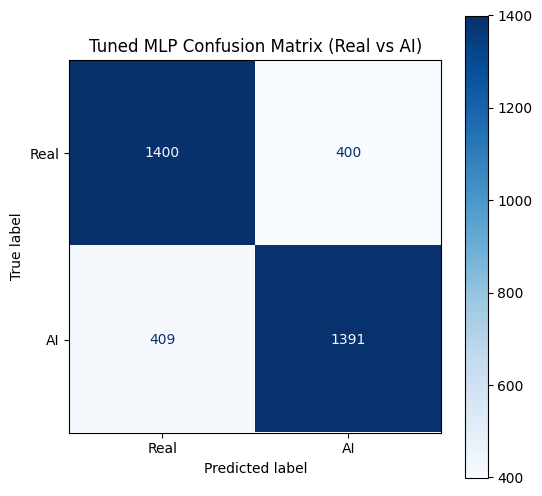

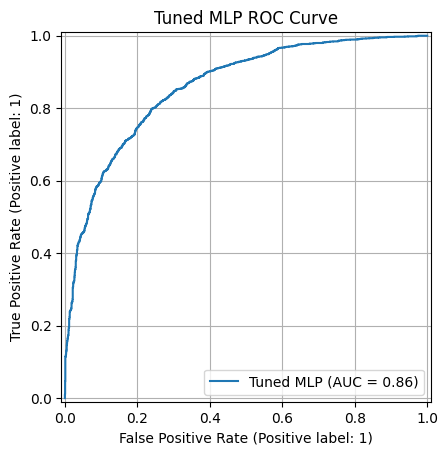

In [10]:
# ============================================
# Step 10: Display Results
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# -------------------------------------------------
# Cross-validation summary (sorted best first)
# -------------------------------------------------
print("Cross-validation summary (top configurations):")

# Display top CV results only when verbose mode is enabled
if VERBOSE:
    display(
        cv_results_df[
            [
                "model_name",
                "hidden_layer_sizes",
                "alpha",
                "cv_accuracy_mean",
                "cv_f1_mean",
                "cv_roc_auc_mean",
                "convergence_warning_count",
            ]
        ].head()
    )

# -------------------------------------------------
# Final tuned model metric summary (test set)
# -------------------------------------------------
# Create a compact summary table of key evaluation metrics
tuned_results_summary_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

print("\nFinal tuned-model test-set summary:")
display(tuned_results_summary_df)

# -------------------------------------------------
# Optional visual displays (enabled via VERBOSE)
# -------------------------------------------------
if VERBOSE:
    # -------------------------------------------------
    # Confusion matrix visualization
    # -------------------------------------------------
    disp_cm = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Real", "AI"]
    )

    fig, ax = plt.subplots(figsize=(6, 6))
    disp_cm.plot(cmap="Blues", values_format="d", ax=ax)
    ax.set_title("Tuned MLP Confusion Matrix (Real vs AI)")
    ax.grid(False)
    plt.show()

    # -------------------------------------------------
    # ROC curve visualization
    # -------------------------------------------------
    RocCurveDisplay.from_predictions(
        y_test_binary,
        y_prob,
        name="Tuned MLP"
    )

    plt.title("Tuned MLP ROC Curve")
    plt.grid(True)
    plt.show()



### 🔷 Step 11 — Save Results

- Save full cross-validation results to CSV file  
- Verify that the results file was successfully created  
- Save best model configuration to JSON file  
- Store selected hyperparameters for reproducibility  
- Compile final tuned-model evaluation metrics into a dictionary  
- Include dataset size, feature count, and training diagnostics  
- Save final tuned-model metrics to CSV file  
- Verify that the tuned results file was successfully created  
- Provide confirmation messages for all saved outputs  

---

In [11]:
# ============================================
# Step 11: Save Results
# ============================================

import pandas as pd
import json

# -------------------------------------------------
# Save full cross-validation results to disk
# -------------------------------------------------
# Persist all evaluated configurations and their metrics
cv_results_df.to_csv(output_results_path, index=False)

# Verify that the file was successfully written
if not output_results_path.exists():
    raise FileNotFoundError(f"Results file was not created: {output_results_path}")

print(f"Cross-validation results saved to: {output_results_path}")

# -------------------------------------------------
# Save best model configuration
# -------------------------------------------------
# Store selected hyperparameters for reproducibility and future use
with open(best_model_config_path, "w") as f:
    json.dump(best_config, f, indent=4)

print(f"Best model configuration saved to: {best_model_config_path}")

# -------------------------------------------------
# Save final tuned model evaluation metrics
# -------------------------------------------------
# Collect key metrics and model diagnostics into a structured dictionary
final_results_dict = {
    "model": best_config["model_name"],
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc,
    "train_samples": len(X_train),
    "test_samples": len(X_test),
    "num_features": X_train.shape[1],
    "training_iterations": final_mlp.n_iter_,
    "final_loss": final_mlp.loss_,
}

# Define output file for final tuned model results
FINAL_RESULTS_FILE = results_dir / "tuned_model_results.csv"

# Convert to DataFrame and save
final_results_df = pd.DataFrame([final_results_dict])
final_results_df.to_csv(FINAL_RESULTS_FILE, index=False)

# Verify that the file was successfully written
if not FINAL_RESULTS_FILE.exists():
    raise FileNotFoundError(f"Tuned results file was not created: {FINAL_RESULTS_FILE}")

print(f"Final tuned model results saved to: {FINAL_RESULTS_FILE}")

# -------------------------------------------------
# Completion message
# -------------------------------------------------
print("\nCell complete.")



Cross-validation results saved to: /content/dip-ai-image-detection/metadata/results/fine_tuning_results.csv
Best model configuration saved to: /content/dip-ai-image-detection/metadata/results/best_model_config.json
Final tuned model results saved to: /content/dip-ai-image-detection/metadata/results/tuned_model_results.csv

Cell complete.


### 🔷 Step 12 — Final Summary and Comparison to Baseline

- Display final tuned-model configuration and training details  
- Report dataset size, feature count, and training diagnostics  
- Present tuned-model test-set performance metrics  
- Provide confusion matrix summary for class-wise performance  
- Load baseline results if available for comparison  
- Construct comparison table between baseline and tuned model  
- Compute absolute performance improvements across all metrics  
- Display comparison results for analysis and reporting  
- Provide final completion message summarizing next steps  

---

In [12]:
# ============================================
# Step 12: Final Summary and Comparison to Baseline
# ============================================

from IPython.display import display, HTML
import pandas as pd

# -------------------------------------------------
# Display final completion and model summary
# -------------------------------------------------
print("Basic fine-tuning completed successfully.\n")

print("Best Tuned Model Summary:")
print(f"Model name         : {best_config['model_name']}")
print(f"Hidden layers      : {selected_candidate['hidden_layer_sizes']}")
print(f"Alpha              : {selected_candidate['alpha']}")
print(f"Learning rate      : {selected_candidate['learning_rate_init']}")
print(f"Training samples   : {len(X_train)}")
print(f"Test samples       : {len(X_test)}")
print(f"Feature count      : {X_train.shape[1]}")
print(f"Training iterations: {final_mlp.n_iter_}")
print(f"Final training loss: {final_mlp.loss_:.6f}")

# -------------------------------------------------
# Display tuned model evaluation metrics
# -------------------------------------------------
print("\nTuned Test Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

# -------------------------------------------------
# Display confusion matrix summary
# -------------------------------------------------
print("\nConfusion Matrix Summary:")
print(f"Real ({REAL_LABEL}): {cm[0,0]} correct, {cm[0,1]} misclassified")
print(f"AI   ({AI_LABEL}): {cm[1,1]} correct, {cm[1,0]} misclassified")

# -------------------------------------------------
# Compare against baseline results if available
# -------------------------------------------------
baseline_results_file = Path(BASIC_TESTING_RESULTS_PATH)

if baseline_results_file.exists():
    baseline_df = pd.read_csv(baseline_results_file)

    if len(baseline_df) > 0:
        baseline_row = baseline_df.iloc[0]

        # Build comparison table between baseline and tuned model
        comparison_df = pd.DataFrame({
            "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"],
            "Baseline": [
                baseline_row["accuracy"],
                baseline_row["precision"],
                baseline_row["recall"],
                baseline_row["f1_score"],
                baseline_row["roc_auc"],
            ],
            "Tuned": [
                accuracy,
                precision,
                recall,
                f1,
                roc_auc,
            ],
        })

        # Compute absolute improvement for each metric
        comparison_df["Absolute Change"] = (
            comparison_df["Tuned"] - comparison_df["Baseline"]
        )

        print("\nBaseline vs Tuned Comparison:")
        display(comparison_df)
    else:
        print("\nBaseline results file exists but is empty. Skipping comparison.")
else:
    print("\nBaseline results file not found. Skipping baseline comparison.")

# -------------------------------------------------
# Final informational message (HTML display)
# -------------------------------------------------
message = """
<b>Fine-Tuning Complete:</b><br>
The tuned MLP model has been selected using cross-validation on the training data and evaluated on the independent test set.<br><br>
"""

display(HTML(f"""
<div style="
    padding: 15px;
    border: 2px solid #4CAF50;
    background-color: #E8F5E9;
    border-radius: 8px;
    font-size: 16px;
">
{message}
</div>
"""))



Basic fine-tuning completed successfully.

Best Tuned Model Summary:
Model name         : MLP_Small_alpha_0.0001
Hidden layers      : (32,)
Alpha              : 0.0001
Learning rate      : 0.001
Training samples   : 14400
Test samples       : 3600
Feature count      : 26
Training iterations: 157
Final training loss: 0.405307

Tuned Test Metrics:
Accuracy : 0.7753
Precision: 0.7767
Recall   : 0.7728
F1-score : 0.7747
ROC AUC  : 0.8596

Confusion Matrix Summary:
Real (rl): 1400 correct, 400 misclassified
AI   (ai): 1391 correct, 409 misclassified

Baseline vs Tuned Comparison:


,Metric,Baseline,Tuned,Absolute Change
0,Accuracy,0.761389,0.775278,0.013889
1,Precision,0.773388,0.776661,0.003274
2,Recall,0.739444,0.772778,0.033333
3,F1-score,0.756035,0.774715,0.018679
4,ROC AUC,0.837383,0.859564,0.022181
